In [63]:
import os
import re
import json
import pandas as pd
from datetime import datetime
from collections import deque
import numpy as np

file_path = "../../edge/processed_topic_samples/plc_processed_line_jam_s03.json"

# JSON 읽기
with open(file_path, "r", encoding="utf-8") as f:
    data = json.load(f)

# timestamp 변환
for obj in data:
    ts = obj.get("timestamp")
    if ts:
        obj["timestamp"] = datetime.fromisoformat(ts.replace("Z", "+00:00"))

# DataFrame 생성
df = pd.DataFrame(data)

# timestamp 없는 행 제거
df = df[df["timestamp"].notna()].copy()

# 정렬
df = df.sort_values("timestamp").reset_index(drop=True)

df.head()

,timestamp,edgeId,equipmentId,jobId,productId,lotId,eventType,previousState,currentState,previousMode,currentMode,durationSec,alarmCode,deltaTotal,deltaGood,deltaReject
0,2026-03-03 08:00:10+00:00,EDGE_01,CNC_01,JOB_001,BRAKEROTER_A,LOT_01,MODE_TRANSITION,NaN,NaN,SETUP,AUTO,NaN,NaN,NaN,NaN,None
1,2026-03-03 08:00:11+00:00,EDGE_01,Conveyor_01,JOB_001,BRAKEROTER_A,LOT_01,MODE_TRANSITION,NaN,NaN,SETUP,AUTO,NaN,NaN,NaN,NaN,None
2,2026-03-03 08:00:20+00:00,EDGE_01,CNC_01,JOB_001,BRAKEROTER_A,LOT_01,STATE_TRANSITION,IDLE,RUN,NaN,NaN,10.0,NaN,NaN,NaN,None
3,2026-03-03 08:00:21+00:00,EDGE_01,Conveyor_01,JOB_001,BRAKEROTER_A,LOT_01,STATE_TRANSITION,IDLE,RUN,NaN,NaN,10.0,NaN,NaN,NaN,None
4,2026-03-03 08:02:50+00:00,EDGE_01,CNC_01,JOB_001,BRAKEROTER_A,LOT_01,STATE_TRANSITION,RUN,COMPLETE,NaN,NaN,150.0,NaN,NaN,NaN,None


In [64]:
# Line_01 제품 기준 PRODUCTION_COMPLETE 이벤트만 추출
line_events = df[(df["equipmentId"] == "Line_01") 
                 & (df["eventType"] == "PRODUCTION_COMPLETE")].sort_values("timestamp").reset_index(drop=True)


# 최근 5개 제품 Window
# deque -> sliding window 구현에 편리
window = deque(maxlen=5)

In [65]:
import pandas as pd
import numpy as np
from datetime import timedelta
from collections import deque

# 이미 timestamp 순으로 정렬된 DataFrame df 사용
line_events = df[(df["equipmentId"] == "Line_01") & 
                 (df["eventType"] == "PRODUCTION_COMPLETE")].reset_index(drop=True)

features_list = []
window_size = 5
window = deque(maxlen=window_size)

for idx, event in line_events.iterrows():
    window.append(event)

    if len(window) == window_size:
        # --- window 기준 시점 ---
        start_ts = window[0]["timestamp"]
        end_ts = window[-1]["timestamp"]

        # 1) Conveyor 상태 Feature
        conveyor_events = df[(df["equipmentId"].str.contains("Conveyor")) &
                             (df["eventType"] == "STATE_TRANSITION") &
                             (df["timestamp"] >= start_ts) &
                             (df["timestamp"] <= end_ts)]
        hold_count = len(conveyor_events[conveyor_events["currentState"]=="HOLD"])
        idle_count = len(conveyor_events[conveyor_events["currentState"]=="IDLE"])
        run_count  = len(conveyor_events[conveyor_events["currentState"]=="RUN"])

        # 2) Manual 모드 Feature
        manual_events = df[(df["equipmentId"].str.contains("Conveyor")) &
                           (df["eventType"] == "MODE_TRANSITION") &
                           (df["previousMode"]=="AUTO") &
                           (df["currentMode"]=="MANUAL") &
                           (df["timestamp"] >= start_ts) &
                           (df["timestamp"] <= end_ts)]
        manual_mode_count = len(manual_events)

        # 3) Alarm Feature
        alarm_events = df[(df["equipmentId"].str.contains("Conveyor")) &
                          (df["eventType"] == "ALARM_ON") &
                          (df["timestamp"] >= start_ts) &
                          (df["timestamp"] <= end_ts)]
        alarm_count = len(alarm_events)
        alarm_rate = alarm_count / len(conveyor_events) if len(conveyor_events) > 0 else 0.0

        # 4) 생산 속도 Feature (interval)
        timestamps = [w["timestamp"] for w in window]
        intervals = [(timestamps[i] - timestamps[i-1]).total_seconds() for i in range(1, len(timestamps))]
        production_interval_avg = np.mean(intervals)
        production_interval_std = np.std(intervals)

        # 5) 품질 Feature
        good_count = sum(1 for w in window if w["deltaGood"] and w["deltaGood"] > 0)
        reject_count = sum(1 for w in window if w["deltaReject"] and w["deltaReject"] > 0)
        reject_rate = reject_count / len(window)

        # 연속 불량 계산
        reject_streak = 0
        current_streak = 0
        for w in window:
            if w["deltaReject"] and w["deltaReject"] > 0:
                current_streak += 1
                reject_streak = max(reject_streak, current_streak)
            else:
                current_streak = 0

        feature_record = {
            "timestamp": end_ts.isoformat(),
            "run_count": run_count,
            "idle_count": idle_count,
            "hold_count": hold_count,
            "manual_mode_count": manual_mode_count,
            "alarm_count": alarm_count,
            "alarm_rate": alarm_rate,
            "production_interval_avg": production_interval_avg,
            "production_interval_std": production_interval_std,
            "good_count": good_count,
            "reject_count": reject_count,
            "reject_rate": reject_rate,
            "reject_streak": reject_streak
        }

        features_list.append(feature_record)

# 결과 DataFrame
features_df = pd.DataFrame(features_list)
print(features_df)

                   timestamp  run_count  idle_count  hold_count  \
0  2026-03-03T08:19:10+00:00          3           2           1   
1  2026-03-03T08:21:50+00:00          3           2           1   
2  2026-03-03T08:24:30+00:00          0           0           0   
3  2026-03-03T08:27:10+00:00          0           0           0   
4  2026-03-03T08:29:50+00:00          0           0           0   
5  2026-03-03T08:32:30+00:00          0           0           0   
6  2026-03-03T08:36:10+00:00          0           0           0   

   manual_mode_count  alarm_count  alarm_rate  production_interval_avg  \
0                  1            4    0.666667                    222.5   
1                  1            4    0.666667                    222.5   
2                  0            0    0.000000                    130.0   
3                  0            0    0.000000                    157.5   
4                  0            0    0.000000                    160.0   
5                  

In [66]:
import json

# JSON 파일로 저장
with open("../../kafka_streams/feature_topic_samples/feature_line_jam_s03.json","w") as f:
    json.dump(features_list, f, ensure_ascii=False, indent=4)


# DataFrame 으로 변환 -> csv로 저장
feature_df = pd.DataFrame(features_list)
feature_df.to_csv("../../kafka_streams/feature_topic_samples/feature_line_jam_s03.csv", index=False)

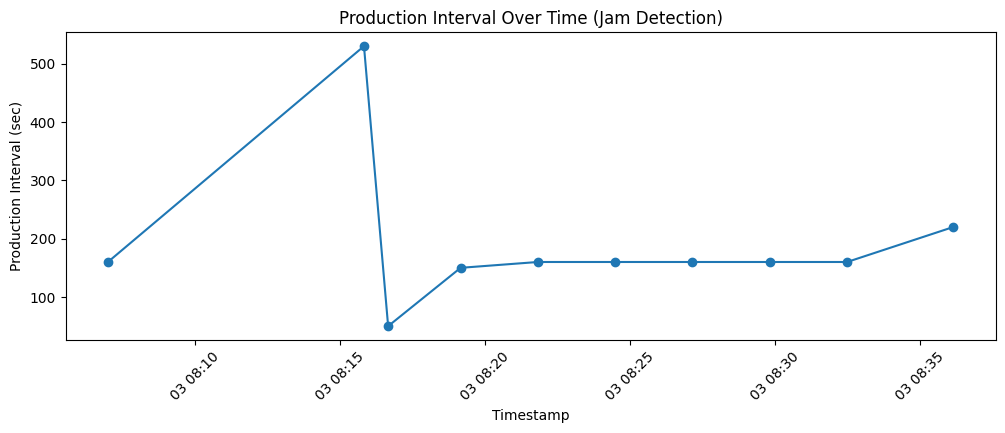

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

line_events["interval"] = line_events["timestamp"].diff().dt.total_seconds()

plt.figure(figsize=(12,4))
plt.plot(line_events["timestamp"], line_events["interval"], marker='o')

plt.ylabel("Production Interval (sec)")
plt.xlabel("Timestamp")
plt.title("Production Interval Over Time (Jam Detection)")
plt.xticks(rotation=45)

plt.show()
